In [1]:
import matplotlib.pyplot as plt
from custom_g4ndl_generator.g4ndl import read_xs, load_target
from custom_g4ndl_generator.cli import main
import tempfile

In [2]:
tmp_folder = tempfile.TemporaryDirectory()

In [4]:
tmp_folder.name

'/tmp/tmpf1ei0t00'

In [5]:
argv_adjust = [
    "--source", "G4NDL.4.7.1",
    "--output", tmp_folder.name,
    "--cache-dir", tmp_folder.name,
    "--rename", "G4NDL.4.7.1_adjusted",
    "-v"
]

main(argv_adjust)

resolving source G4NDL.4.7.1
downloading https://cern.ch/geant4-data/datasets/G4NDL.4.7.1.tar.gz


downloading G4NDL.4.7.1 from https://cern.ch/geant4-data/datasets/G4NDL.4.7.1.tar.gz ...


    0.1% (1/1061 MB)
    0.2% (2/1061 MB)
    0.3% (3/1061 MB)
    0.4% (4/1061 MB)
    0.5% (5/1061 MB)
    0.6% (6/1061 MB)
    0.7% (7/1061 MB)
    0.8% (8/1061 MB)
    0.8% (9/1061 MB)
    0.9% (10/1061 MB)
    1.0% (11/1061 MB)
    1.1% (12/1061 MB)
    1.2% (13/1061 MB)
    1.3% (14/1061 MB)
    1.4% (15/1061 MB)
    1.5% (16/1061 MB)
    1.6% (17/1061 MB)
    1.7% (18/1061 MB)
    1.8% (19/1061 MB)
    1.9% (20/1061 MB)
    2.0% (21/1061 MB)
    2.1% (22/1061 MB)
    2.2% (23/1061 MB)
    2.3% (24/1061 MB)
    2.4% (25/1061 MB)
    2.4% (26/1061 MB)
    2.5% (27/1061 MB)
    2.6% (28/1061 MB)
    2.7% (29/1061 MB)
    2.8% (30/1061 MB)
    2.9% (31/1061 MB)
    3.0% (32/1061 MB)
    3.1% (33/1061 MB)
    3.2% (34/1061 MB)
    3.3% (35/1061 MB)
    3.4% (36/1061 MB)
    3.5% (37/1061 MB)
    3.6% (38/1061 MB)
    3.7% (39/1061 MB)
    3.8% (40/1061 MB)
    3.9% (41/1061 MB)
    4.0% (42/1061 MB)
    4.1% (43/1061 MB)
    4.1% (44/1061 MB)
    4.2% (45/1061 MB)
    4.3% (46/1061 M

wrote modified library: /tmp/tmpf1ei0t00/G4NDL.4.7.1_adjusted
wrote tarball:          /tmp/tmpf1ei0t00/G4NDL.4.7.1_adjusted.tar.gz


0

In [ ]:
! ls /tmp/tmpf1ei0t00/extracted/G4NDL.4.7.1/G4NDL4.7.1/

Capture  Inelastic	    README	 README.old3   ThermalScattering
Elastic  IsotopeProduction  README.old	 README.old4
Fission  JENDL_HE	    README.old2  README.v3.16


In [27]:
adjusted = read_xs(load_target(f"{tmp_folder.name}/G4NDL.4.7.1_adjusted/Capture/CrossSection/32_76_Germanium.z"))
original = read_xs(load_target(f"{tmp_folder.name}/extracted/G4NDL.4.7.1/G4NDL4.7.1/Capture/CrossSection/32_76_Germanium.z"))

In [28]:
original_data = original[0]
adjusted_data = adjusted[0]

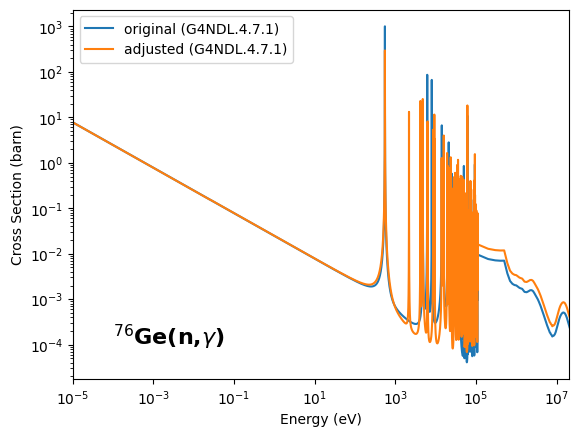

<Figure size 640x480 with 0 Axes>

In [37]:
plt.plot(original_data[:,0], original_data[:,1], label="original (G4NDL.4.7.1)")
plt.plot(adjusted_data[:,0], adjusted_data[:,1], label="adjusted (G4NDL.4.7.1)")
plt.text(1e-4,1e-4, r"$^{76}$Ge(n,$\gamma$)", size=16, weight="bold")
plt.xlabel("Energy (eV)")
plt.ylabel("Cross Section (barn)")
plt.yscale("log")
plt.xscale("log")
plt.xlim(1e-5,2e7)
plt.legend()
plt.show()
plt.savefig("./comparison_plot.png")

In [ ]:
tmp_folder.cleanup()